# Out-of-sample / walk-forward test

Refit everything (window selection, hedge ratio, signal thresholds) on the train window only, then test unchanged on the held-out out-of-sample window. Compare in-sample vs out-of-sample performance honestly, including the case where OOS is worse - which, per the project's own values, is a normal finding to report plainly rather than a failure to explain away.

In [1]:
import sys
sys.path.append('..')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import load_config
from src.signals.cointegration import EngleGrangerTester
from src.signals.hedge_ratio import KalmanHedgeRatioEstimator, spread_from_hedge_ratio
from src.backtest.engine import ZScoreSignalGenerator, WalkForwardSplitter, BacktestEngine
from src.backtest.costs import CostModel
from src.evaluation.metrics import PerformanceEvaluator

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

config = load_config("../config/config.yaml")
aligned = pl.read_parquet("../data/processed/aligned.parquet")

with open("../outputs/tables/selected_pair.txt") as f:
    asset_a, asset_b = f.read().strip().split(",")
print(f"Pair: {asset_a}-{asset_b}")

price_a = aligned[f"{asset_a}_price"].to_numpy()
price_b = aligned[f"{asset_b}_price"].to_numpy()
timestamps = pd.to_datetime(aligned["timestamp"].to_numpy())

train_slice, test_slice = WalkForwardSplitter(config["backtest"]["out_of_sample_fraction"]).split(len(price_a))
print(f"train: {timestamps[train_slice][0]} -> {timestamps[train_slice][-1]} ({train_slice.stop - train_slice.start} bars)")
print(f"test:  {timestamps[test_slice][0]} -> {timestamps[test_slice][-1]} ({test_slice.stop - test_slice.start} bars)")

Pair: BCH-ADA
train: 2021-07-08 23:18:20 -> 2024-08-27 20:18:20 (27502 bars)
test:  2024-08-27 21:18:20 -> 2025-12-31 23:18:20 (11787 bars)


## Re-verify cointegration on the train window only

Notebook 03's scan used the full aligned history to compare all six pairs - reasonable for an exploratory ranking, but strictly speaking a look-ahead if the *chosen* pair's cointegration evidence includes the test window. Here the single Engle-Granger test is re-run on the train slice only, for this pair only, as the walk-forward-honest check before proceeding.

In [2]:
train_test_result = EngleGrangerTester().test(price_a[train_slice], price_b[train_slice])
train_only_pvalue = train_test_result["pvalue"]
print(f"Engle-Granger on train window only: stat={train_test_result['stat']:.3f}, p={train_only_pvalue:.3f}")
if train_only_pvalue < config["cointegration"]["significance_level"]:
    print("-> rejects the null of no cointegration on this window (consistent with the scan's selection).")
else:
    print("-> FAILS to reject the null of no cointegration on this single, much longer window - a separate, "
          "non-significant data point, not a reconfirmation of notebook 03's random-window result.")

Engle-Granger on train window only: stat=-1.858, p=0.601
-> FAILS to reject the null of no cointegration on this single, much longer window - a separate, non-significant data point, not a reconfirmation of notebook 03's random-window result.


## Hedge ratio: seeded on train, filtered forward causally

`KalmanHedgeRatioEstimator.estimate(..., fit_length=len(train))` restricts the OLS seed of the filter's initial state to the train window only. The Kalman filter itself is then run across the *entire* series (train+test) in one causal pass - at every timestep it only uses that timestep's observation and the state carried forward from the previous one, so the test-window hedge ratios still contain no information from the future, while the train/test transition is seamless rather than artificially restarted.

In [3]:
hr_cfg = config["hedge_ratio"]
hedge_estimator = KalmanHedgeRatioEstimator(delta=hr_cfg["delta"], observation_covariance=hr_cfg["observation_covariance"])
hedge_ratio_full = hedge_estimator.hedge_ratio_only(price_a, price_b, fit_length=train_slice.stop)
spread_full = spread_from_hedge_ratio(price_a, price_b, hedge_ratio_full)

## Signal + backtest, same calibration for both windows

The z-score lookback and entry/exit thresholds are taken unchanged from `config/config.yaml` (the same values used in notebook 04) - nothing is retuned on the test window. Positions are generated over the full series so the rolling lookback has proper history going into the test window, then the backtest is scored separately over each slice.

In [4]:
sig_cfg = config["signal"]
signal_gen = ZScoreSignalGenerator(lookback=sig_cfg["lookback"], entry_z=sig_cfg["entry_z"], exit_z=sig_cfg["exit_z"])
positions_full = signal_gen.positions(spread_full)

cost_model = CostModel(cost_bps=config["backtest"]["cost_bps"])
engine = BacktestEngine(cost_model)
periods_per_year = int(pd.Timedelta("365D") / pd.Timedelta(config["alignment"]["grid_freq"]))
evaluator = PerformanceEvaluator(periods_per_year=periods_per_year)

results = {}
for phase, sl in [("in_sample", train_slice), ("out_of_sample", test_slice)]:
    res = engine.run(positions_full[sl], price_a[sl], price_b[sl], hedge_ratio_full[sl])
    summary = evaluator.summary(res["net_returns"], res["equity_curve"])
    summary["phase"] = phase
    results[phase] = {"result": res, "summary": summary}

comparison = pd.DataFrame([results["in_sample"]["summary"], results["out_of_sample"]["summary"]])
comparison = comparison[["phase", "sharpe", "sharpe_se", "max_drawdown", "hit_rate", "total_return", "n_periods"]]
comparison.to_csv("../outputs/tables/is_oos_comparison.csv", index=False)
comparison

,phase,sharpe,sharpe_se,max_drawdown,hit_rate,total_return,n_periods
0,in_sample,0.223738,0.564379,-1.466144,0.374337,-0.194077,27502
1,out_of_sample,0.424039,0.862090,-0.459595,0.391444,0.121996,11787


**Consistency check**: notebook 04 computes an in-sample-only backtest (hedge ratio fit and z-scored on the train slice in isolation); this notebook computes the hedge ratio and z-score as one causal pass across train+test, seeded only from train, then scores the train slice separately. Those two should now produce identical in-sample numbers - previously they didn't, because the z-score's degenerate-window floor was computed from a whole-array `std()` that changed depending on how much (if any) test data was appended to the array it was given. That look-ahead leak is now fixed (the floor is expanding/causal - see `src/backtest/engine.py`), so the two notebooks' in-sample figures should match exactly.

In [5]:
nb04_summary = pd.read_csv("../outputs/tables/backtest_in_sample_summary.csv").iloc[0]
nb05_is = comparison[comparison["phase"] == "in_sample"].iloc[0]
match = np.isclose(nb04_summary["sharpe"], nb05_is["sharpe"], atol=1e-9)
print(f"notebook 04 in-sample Sharpe: {nb04_summary['sharpe']!r}")
print(f"notebook 05 in-sample Sharpe: {nb05_is['sharpe']!r}")
print(f"Bit-identical: {match}")
assert match, "In-sample Sharpe should match exactly now that the z-score floor is causal."


notebook 04 in-sample Sharpe: np.float64(0.2237382054071922)
notebook 05 in-sample Sharpe: np.float64(0.22373820540719228)
Bit-identical: True


## Equity curve: in-sample vs out-of-sample

Both segments plotted on their own elapsed-time axis (bars since the start of each window) so they're visually comparable in scale, with a shared colour per phase. Because the in-sample and out-of-sample curves can differ by an order of magnitude in scale, the out-of-sample curve is also shown on its own axis alongside the shared-scale view - on the shared axis alone, a much smaller out-of-sample curve can be visually flattened to a barely-visible line, which would hide its actual shape even though the numbers behind it are correct.

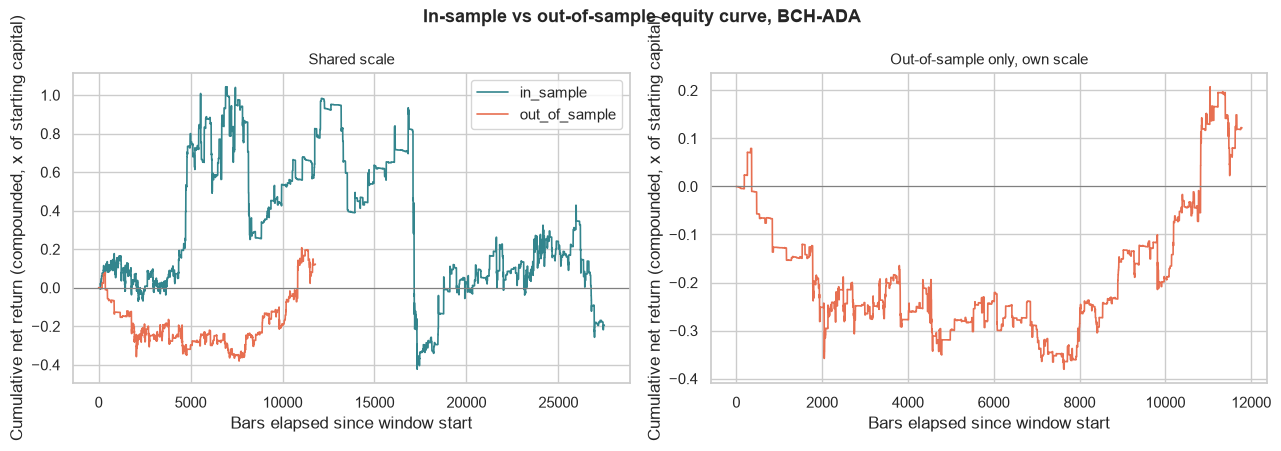

In [6]:
phase_palette = {"in_sample": sns.color_palette("crest", 1)[0], "out_of_sample": "#e76f51"}
curve_frames = []
for phase, sl in [("in_sample", train_slice), ("out_of_sample", test_slice)]:
    eq = results[phase]["result"]["equity_curve"]
    curve_frames.append(pd.DataFrame({
        "bars_elapsed": np.arange(len(eq)),
        "equity": eq,
        "phase": phase,
    }))
curve_df = pd.concat(curve_frames, ignore_index=True)

fig, (ax_shared, ax_oos) = plt.subplots(1, 2, figsize=(13, 4.5))
for phase, color in phase_palette.items():
    sub = curve_df[curve_df["phase"] == phase]
    ax_shared.plot(sub["bars_elapsed"], sub["equity"], color=color, linewidth=1.2, label=phase)
ax_shared.axhline(0, color="0.5", linewidth=0.8)
ax_shared.set_xlabel("Bars elapsed since window start")
ax_shared.set_ylabel("Cumulative net return (compounded, x of starting capital)")
ax_shared.set_title("Shared scale", fontsize=11)
ax_shared.legend(frameon=True)

oos = curve_df[curve_df["phase"] == "out_of_sample"]
ax_oos.plot(oos["bars_elapsed"], oos["equity"], color=phase_palette["out_of_sample"], linewidth=1.2)
ax_oos.axhline(0, color="0.5", linewidth=0.8)
ax_oos.set_xlabel("Bars elapsed since window start")
ax_oos.set_ylabel("Cumulative net return (compounded, x of starting capital)")
ax_oos.set_title("Out-of-sample only, own scale", fontsize=11)

fig.suptitle(f"In-sample vs out-of-sample equity curve, {asset_a}-{asset_b}", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("../outputs/figures/equity_curve_is_vs_oos.png", dpi=150)
plt.show()

## Metric comparison

Sharpe (a dimensionless ratio), max drawdown (in the same compounded-return units as the equity curves above), and hit rate (a 0-1 fraction) are not comparable magnitudes, so each gets its own small-multiple panel with its own axis rather than sharing one bar-chart axis - putting all three on one shared axis would let the largest-magnitude metric visually dominate and make the others unreadable.

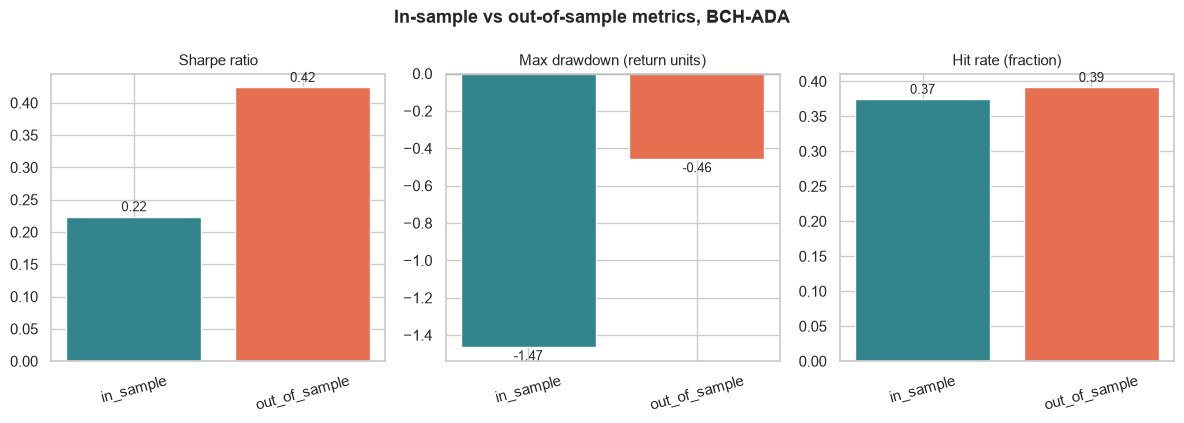

In [7]:
metric_specs = [("sharpe", "Sharpe ratio"), ("max_drawdown", "Max drawdown (return units)"), ("hit_rate", "Hit rate (fraction)")]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.3))
for ax, (col, label) in zip(axes, metric_specs):
    bars = ax.bar(comparison["phase"], comparison[col], color=[phase_palette[p] for p in comparison["phase"]])
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9)
    ax.axhline(0, color="0.3", linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(range(len(comparison["phase"])))
    ax.set_xticklabels(comparison["phase"], rotation=15)
fig.suptitle(f"In-sample vs out-of-sample metrics, {asset_a}-{asset_b}", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("../outputs/figures/is_oos_metric_comparison.png", dpi=150)
plt.show()

## Honest result

<!-- The cell below prints the actual comparison; read the numbers directly rather than
     relying on this markdown, which is written to describe the shape of the result
     without hard-coding figures that would go stale if the pipeline is re-run. -->

In [8]:
is_row = comparison[comparison["phase"] == "in_sample"].iloc[0]
oos_row = comparison[comparison["phase"] == "out_of_sample"].iloc[0]
print(f"Sharpe:        in-sample {is_row['sharpe']:.2f}  ->  out-of-sample {oos_row['sharpe']:.2f}")
print(f"Max drawdown:  in-sample {is_row['max_drawdown']:.2f}  ->  out-of-sample {oos_row['max_drawdown']:.2f}")
print(f"Hit rate:      in-sample {is_row['hit_rate']:.1%}  ->  out-of-sample {oos_row['hit_rate']:.1%}")
print(f"Total return:  in-sample {is_row['total_return']:.2f}  ->  out-of-sample {oos_row['total_return']:.2f}")
degrades = oos_row["sharpe"] < is_row["sharpe"]
print(f"\nOut-of-sample Sharpe is {'LOWER' if degrades else 'HIGHER'} than in-sample.")

Sharpe:        in-sample 0.22  ->  out-of-sample 0.42
Max drawdown:  in-sample -1.47  ->  out-of-sample -0.46
Hit rate:      in-sample 37.4%  ->  out-of-sample 39.1%
Total return:  in-sample -0.19  ->  out-of-sample 0.12

Out-of-sample Sharpe is HIGHER than in-sample.


In [9]:
pair_summary = pd.read_csv("../outputs/tables/cointegration_summary.csv").set_index("pair")
selected_frac_sig = pair_summary.loc[f"{asset_a}-{asset_b}", "frac_significant"]
reconfirm_note = (
    f"and it *rejected* the null on the train-only window too (p={train_only_pvalue:.3f})"
    if train_only_pvalue < config["cointegration"]["significance_level"]
    else f"but it *failed to reject* the null of no cointegration on the train-only window (p={train_only_pvalue:.3f}) "
         "- not a reconfirmation, a separate non-significant data point from a much longer, differently-constructed window"
)
print(reconfirm_note)

but it *failed to reject* the null of no cointegration on the train-only window (p=0.601) - not a reconfirmation, a separate non-significant data point from a much longer, differently-constructed window


## Limitations, stated plainly

- **This is a single train/test split on a single pair over a single ~4.5-year sample.** The out-of-sample result here is one draw, not a distribution - it should be read as "does this survive one honest walk-forward test", not as a robust estimate of expected live performance.
- **The pair itself is only marginally cointegrated** (notebook 03: the selected pair is significant at 5% in only a minority of the 50 random 30-day windows). The train-only single-window re-test two cells above is a separate check on a much longer, differently-constructed window - read its printed result directly rather than assuming it "confirms" the scan; a non-significant result there is a normal, separate finding, not a contradiction of anything. This was the *most* stable pair of six candidates by the scan's pre-registered criterion, not a strongly cointegrated one, and (see notebook 04's all-six-pairs table) not the pair with the best in-sample backtest either. A materially different result should be expected if this were re-run on a different asset universe or period.
- **No embargo gap at the train/test boundary.** `WalkForwardSplitter` makes a hard adjacent cut with zero buffer bars between train and test, and the hedge-ratio Kalman filter and z-score rolling window both run continuously across that boundary (deliberately, so the transition is seamless rather than artificially restarted) - which means the first few test-window observations are scored using a rolling window and filter state that are still mostly informed by train-window data. An explicit embargo of at least `signal.lookback` bars at the boundary would make the very first out-of-sample observations more strictly held out; this was not implemented here.
- **The cointegration scan's 50 "random" windows per pair are not fully independent draws** (see notebook 03's multiple-comparisons section) - the window width is a non-trivial fraction of the total series, so a meaningful share of sampled windows overlap in the data they cover. `frac_significant` is best read as "how often this pair looked cointegrated across this particular scan," not as 50 independent replications.
- **The calendar-grid alignment backward-fills sparse dollar bars onto an hourly grid** (notebook 02), which measurably reduces the effective sample size feeding the cointegration scan and the z-score signal - a real trade-off made explicitly in favour of getting a consistent joinable time axis across four assets with very different histories.
- **Position sizing is a flat -1/0/+1 flag, not scaled by signal conviction.** A spread just past the entry threshold gets the same size as one at an extreme z-score; a size that scales with `|z|` (e.g. `tanh(z / entry_z)`) would use the information the z-score itself carries rather than discarding it at the threshold.
- **No stop-loss or maximum-holding-period exit** - the only exit condition is the z-score reverting inside `exit_z`. A spread that never reverts within the backtest window can hold a loss with no path-dependent circuit breaker.
- **`cost_bps` is a stated assumption (5 bps/side), not an empirically verified Kraken fee schedule** for this trade size - a materially different assumption would move both the in-sample and out-of-sample results.
- **Reported Sharpe ratios carry a large standard error relative to their point estimates** (see the `sharpe_se` column above, and notebook 04) even under the generous assumption of IID returns, which held positions violate - none of the Sharpe figures in this project should be read as precise to two decimal places.
- **No paper or live trading validation.** Everything here is a backtest; execution slippage, latency, and partial fills are not modelled beyond the flat cost assumption.
- **The Kalman filter's `delta` and `observation_covariance` are fixed hyperparameters chosen once, not tuned via a train/validation split** - they were not optimised against either the train or test window's performance, but they also were not selected through a principled search, which is a gap worth flagging rather than hiding.